<a href="https://colab.research.google.com/github/yejxjj/2026-1_CV/blob/main/HW3_%EC%8B%A4%ED%97%98A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
import time
from dataclasses import dataclass, field
from typing import List, Dict, Optional


In [ ]:
# ====== 실험 설정 ======

@dataclass
class ExperimentConfig:
    img_input_dim: int = 28 * 28      # Fashion-MNIST 입력 차원
    n_classes: int = 10                # 클래스 개수
    batch_size: int = 64
    n_epochs: int = 30                 # Fashion-MNIST는 20~50
    learning_rate: float = 0.05        # SGD 가이드 범위 (0.01~0.1) 내
    convergence_threshold: float = 0.85  # 수렴 판정 기준 (Val Acc 85%)
    seed: int = 2025

CFG = ExperimentConfig()

# 디바이스 자동 선택 (GPU 있으면 CUDA, 없으면 CPU)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {DEVICE}")

# ====== 재현성 시드 고정 ======

def fix_seed(seed: int):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

fix_seed(CFG.seed)

사용 디바이스: cuda


In [ ]:
# ====== 네트워크 구조 정의 ======

class ClassifierNet(nn.Module):

    def __init__(self, in_dim: int, out_dim: int):
        super().__init__()
        # 첫 번째 은닉층 (입력 → 256)
        self.hidden_layer1 = nn.Linear(in_dim, 256)
        # 두 번째 은닉층 (256 → 128)
        self.hidden_layer2 = nn.Linear(256, 128)
        # 출력층 (128 → 클래스 수)
        # 출력은 logit 그대로 (CrossEntropy는 내부 softmax, MSE는 외부 softmax 적용)
        self.output_layer = nn.Linear(128, out_dim)

        self.activation = nn.ReLU()

    def forward(self, x):
        # 이미지를 flatten: (B, 1, 28, 28) → (B, 784)
        x = x.view(x.size(0), -1)
        h1 = self.activation(self.hidden_layer1(x))   # 첫 ReLU 출력
        h2 = self.activation(self.hidden_layer2(h1))  # 두 번째 ReLU 출력
        logits = self.output_layer(h2)                 # raw logit
        return logits

In [ ]:
# ====== Fashion-MNIST 데이터 로더 ======
# 데이터셋: Fashion-MNIST

def build_fashion_mnist_loaders(batch_size: int):
    # 픽셀값을 [-1, 1] 범위로 정규화 (학습 안정성을 위해)
    transform_pipeline = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5,), std=(0.5,))
    ])

    train_set = datasets.FashionMNIST(
        root="./data", train=True, download=True, transform=transform_pipeline
    )
    test_set = datasets.FashionMNIST(
        root="./data", train=False, download=True, transform=transform_pipeline
    )

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader


def to_one_hot(label_tensor: torch.Tensor, n_classes: int) -> torch.Tensor:
    return F.one_hot(label_tensor, num_classes=n_classes).float()

In [ ]:
# ====== 손실 계산 모드 정의 ======
# 3가지 비교군:
#   1. "ce"           : CrossEntropy (내부 softmax 포함)
#   2. "mse_softmax"  : MSE + softmax
#   3. "mse_raw"      : MSE + softmax 없음

def compute_loss_and_pred(loss_mode: str, logits: torch.Tensor,
                          labels: torch.Tensor, n_classes: int):

    if loss_mode == "ce":
        # CrossEntropy는 logits을 그대로 받아서 내부적으로 log_softmax 적용
        loss_fn = nn.CrossEntropyLoss()
        loss = loss_fn(logits, labels)
        predicted = torch.argmax(logits, dim=1)

    elif loss_mode == "mse_softmax":
        # MSE는 softmax 확률 vs 원-핫 라벨을 비교
        probs = torch.softmax(logits, dim=1)
        one_hot = to_one_hot(labels, n_classes).to(logits.device)
        loss_fn = nn.MSELoss()
        loss = loss_fn(probs, one_hot)
        predicted = torch.argmax(probs, dim=1)

    elif loss_mode == "mse_raw":
        # Ablation: softmax 없이 raw logit과 원-핫을 직접 MSE 비교
        # 출력값 범위가 [0,1]로 제약되지 않아서 학습이 불안정함을 보이는게 목적
        one_hot = to_one_hot(labels, n_classes).to(logits.device)
        loss_fn = nn.MSELoss()
        loss = loss_fn(logits, one_hot)
        predicted = torch.argmax(logits, dim=1)

    else:
        raise ValueError(f"알 수 없는 손실 모드: {loss_mode}")

    return loss, predicted

In [ ]:
# ====== 검증 데이터 평가 함수 ======

@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, loss_mode: str, n_classes: int):

    model.eval()  # 평가 모드 전환 (Dropout/BatchNorm 비활성화)

    total_loss = 0.0
    n_correct = 0
    n_total = 0

    # torch.no_grad() 컨텍스트는 위에 데코레이터로 적용됨
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        loss, pred = compute_loss_and_pred(loss_mode, logits, labels, n_classes)

        total_loss += loss.item() * imgs.size(0)
        n_correct += (pred == labels).sum().item()
        n_total += labels.size(0)

    avg_loss = total_loss / n_total
    accuracy = n_correct / n_total
    return avg_loss, accuracy

In [ ]:
# ====== Forward Hook으로 중간 레이어 출력 캡처 ======
# 학습 초반/중반/후반 시점의 히든 레이어 출력 분포를 시각화하기 위함

class ActivationRecorder:

    def __init__(self):
        self.captured = {}   # {epoch_tag: {layer_name: numpy array}}
        self._hooks = []
        self._current_tag = None
        self._target_layers = {}

    def attach(self, model: nn.Module):

        # ReLU 이후 출력을 잡기 위해 forward에서 직접 후킹하는 대신
        # 두 hidden layer의 출력에 ReLU를 한 번 더 적용한 값을 기록하는 방식 사용

        def make_hook(layer_id):
            def _hook(module, inp, out):
                if self._current_tag is not None:
                    relu_out = torch.relu(out).detach().cpu().numpy().flatten()
                    self.captured.setdefault(self._current_tag, {})[layer_id] = relu_out
            return _hook

        h1 = model.hidden_layer1.register_forward_hook(make_hook("hidden1"))
        h2 = model.hidden_layer2.register_forward_hook(make_hook("hidden2"))
        self._hooks = [h1, h2]

    def set_tag(self, tag: Optional[str]):
        """현재 캡처할 태그 지정. None이면 캡처 안 함."""
        self._current_tag = tag

    def detach(self):
        for h in self._hooks:
            h.remove()
        self._hooks = []

In [ ]:
# ====== 학습 루프 ======

@dataclass
class TrainingLog:
    train_losses: List[float] = field(default_factory=list)
    train_accs: List[float] = field(default_factory=list)
    val_losses: List[float] = field(default_factory=list)
    val_accs: List[float] = field(default_factory=list)
    grad_norms_h1: List[float] = field(default_factory=list)  # hidden_layer1 gradient norm
    grad_norms_h2: List[float] = field(default_factory=list)
    grad_norms_out: List[float] = field(default_factory=list)
    convergence_epoch: Optional[int] = None
    total_time: float = 0.0


def run_training_loop(model, train_loader, test_loader, optimizer,
                      loss_mode, cfg: ExperimentConfig,
                      activation_recorder: Optional[ActivationRecorder] = None):

    model.to(DEVICE)
    log = TrainingLog()

    capture_epochs = {
    1: "early",
    cfg.n_epochs // 2: "mid",
    cfg.n_epochs: "late",
}


    print(f"\n[{loss_mode}] 학습 시작 - 총 {cfg.n_epochs} 에폭")
    start_time = time.time()

    for epoch in range(1, cfg.n_epochs + 1):
        model.train()
        running_loss = 0.0
        n_correct, n_total = 0, 0

        # 에폭별 gradient norm을 평균내기 위한 누적 변수
        h1_grad_sum, h2_grad_sum, out_grad_sum = 0.0, 0.0, 0.0
        n_batches = 0

        # Activation 캡처 - 이번 에폭이 캡처 시점이면 태그 설정
        if activation_recorder is not None and epoch in capture_epochs:
            activation_recorder.set_tag(capture_epochs[epoch])
        else:
            if activation_recorder is not None:
                activation_recorder.set_tag(None)

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()

            logits = model(imgs)
            loss, pred = compute_loss_and_pred(loss_mode, logits, labels, cfg.n_classes)

            # autograd 역전파
            loss.backward()

            # 레이어별 gradient L2 norm 계산 (Gradient flow 분석용)
            if model.hidden_layer1.weight.grad is not None:
                h1_grad_sum += model.hidden_layer1.weight.grad.norm().item()
            if model.hidden_layer2.weight.grad is not None:
                h2_grad_sum += model.hidden_layer2.weight.grad.norm().item()
            if model.output_layer.weight.grad is not None:
                out_grad_sum += model.output_layer.weight.grad.norm().item()
            n_batches += 1

            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            n_correct += (pred == labels).sum().item()
            n_total += labels.size(0)

        # Activation 캡처 태그 해제 (다음 에폭에서 또 캡처되지 않도록)
        if activation_recorder is not None:
            activation_recorder.set_tag(None)

        # 에폭 통계 정리
        train_loss = running_loss / n_total
        train_acc = n_correct / n_total
        val_loss, val_acc = evaluate(model, test_loader, loss_mode, cfg.n_classes)

        log.train_losses.append(train_loss)
        log.train_accs.append(train_acc)
        log.val_losses.append(val_loss)
        log.val_accs.append(val_acc)
        log.grad_norms_h1.append(h1_grad_sum / n_batches)
        log.grad_norms_h2.append(h2_grad_sum / n_batches)
        log.grad_norms_out.append(out_grad_sum / n_batches)

        # 수렴 epoch 자동 판정 (Val Acc가 임계값 처음 돌파한 시점)
        if log.convergence_epoch is None and val_acc >= cfg.convergence_threshold:
            log.convergence_epoch = epoch

        print(f"  Ep {epoch:2d}/{cfg.n_epochs} | "
              f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
              f"Val Loss {val_loss:.4f} Acc {val_acc:.4f}")

    log.total_time = time.time() - start_time
    print(f"  → 학습 완료 ({log.total_time:.1f}초)")
    if log.convergence_epoch is not None:
        print(f"  → 수렴 epoch: {log.convergence_epoch} (Val Acc {cfg.convergence_threshold*100:.0f}% 돌파)")
    else:
        print(f"  → {cfg.convergence_threshold*100:.0f}% 미수렴")

    return log

In [ ]:
# ====== 실험 실행: 3가지 손실 모드 비교 ======
# 동일 시드 / 동일 네트워크 / 동일 optimizer로 손실 함수만 바꿔서 비교

# 데이터 로더는 한 번만 만들고 재사용
train_loader, test_loader = build_fashion_mnist_loaders(CFG.batch_size)
print(f"훈련 데이터: {len(train_loader.dataset)}개")
print(f"테스트 데이터: {len(test_loader.dataset)}개")

# 비교할 손실 모드 리스트
loss_modes_to_run = ["ce", "mse_softmax", "mse_raw"]
mode_display_names = {
    "ce": "CrossEntropy",
    "mse_softmax": "MSE (with Softmax)",
    "mse_raw": "MSE (no Softmax, Ablation)"
}

# 결과 저장소
all_logs: Dict[str, TrainingLog] = {}
all_activations: Dict[str, ActivationRecorder] = {}

for mode in loss_modes_to_run:
    print(f"\n{'='*60}")
    print(f"실험: {mode_display_names[mode]}")
    print(f"{'='*60}")

    # 매 실험마다 시드 재고정
    fix_seed(CFG.seed)

    # 새 모델, 새 optimizer 생성
    model = ClassifierNet(in_dim=CFG.img_input_dim, out_dim=CFG.n_classes)

    # SGD 선택 이유: CE vs MSE 차이가 이론대로 뚜렷이 드러나도록
    # (Adam을 쓰면 MSE도 너무 잘 학습되어 차이가 안 보임)
    optimizer = optim.SGD(model.parameters(), lr=CFG.learning_rate)

    # Activation 기록기 부착
    recorder = ActivationRecorder()
    recorder.attach(model)

    log = run_training_loop(model, train_loader, test_loader, optimizer,
                            mode, CFG, activation_recorder=recorder)

    recorder.detach()

    all_logs[mode] = log
    all_activations[mode] = recorder

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.86MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 172kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.19MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.6MB/s]


훈련 데이터: 60000개
테스트 데이터: 10000개

실험: CrossEntropy

[ce] 학습 시작 - 총 30 에폭
  Ep  1/30 | Train Loss 0.6278 Acc 0.7748 | Val Loss 0.4894 Acc 0.8226
  Ep  2/30 | Train Loss 0.4225 Acc 0.8451 | Val Loss 0.5074 Acc 0.8067
  Ep  3/30 | Train Loss 0.3780 Acc 0.8615 | Val Loss 0.4288 Acc 0.8426
  Ep  4/30 | Train Loss 0.3490 Acc 0.8729 | Val Loss 0.3889 Acc 0.8604
  Ep  5/30 | Train Loss 0.3263 Acc 0.8814 | Val Loss 0.3562 Acc 0.8732
  Ep  6/30 | Train Loss 0.3108 Acc 0.8856 | Val Loss 0.3725 Acc 0.8668
  Ep  7/30 | Train Loss 0.2956 Acc 0.8913 | Val Loss 0.3604 Acc 0.8714
  Ep  8/30 | Train Loss 0.2832 Acc 0.8962 | Val Loss 0.3565 Acc 0.8724
  Ep  9/30 | Train Loss 0.2717 Acc 0.9009 | Val Loss 0.3779 Acc 0.8659
  Ep 10/30 | Train Loss 0.2621 Acc 0.9029 | Val Loss 0.3467 Acc 0.8755
  Ep 11/30 | Train Loss 0.2536 Acc 0.9067 | Val Loss 0.3484 Acc 0.8737
  Ep 12/30 | Train Loss 0.2448 Acc 0.9098 | Val Loss 0.4743 Acc 0.8434
  Ep 13/30 | Train Loss 0.2357 Acc 0.9124 | Val Loss 0.3460 Acc 0.8770
  Ep 1

In [ ]:
# ====== 정량 비교표 출력 ======
print("\n" + "="*95)
print(f"{'손실 함수':<28} | {'최종 정확도(%)':<14} | {'Loss 최솟값':<13} | {'수렴 epoch':<11} | {'학습 시간(s)':<12}")
print("-"*95)
for mode in loss_modes_to_run:
    log = all_logs[mode]
    name = mode_display_names[mode]
    final_acc = log.val_accs[-1] * 100
    min_loss = min(log.val_losses)
    conv_ep = str(log.convergence_epoch) if log.convergence_epoch else "미수렴"
    print(f"{name:<28} | {final_acc:<14.2f} | {min_loss:<13.4f} | {conv_ep:<11} | {log.total_time:<12.1f}")
print("="*95)


손실 함수                        | 최종 정확도(%)      | Loss 최솟값      | 수렴 epoch    | 학습 시간(s)    
-----------------------------------------------------------------------------------------------
CrossEntropy                 | 89.05          | 0.3196        | 4           | 467.3       
MSE (with Softmax)           | 85.32          | 0.0211        | 27          | 471.8       
MSE (no Softmax, Ablation)   | 87.19          | 0.0202        | 10          | 462.6       


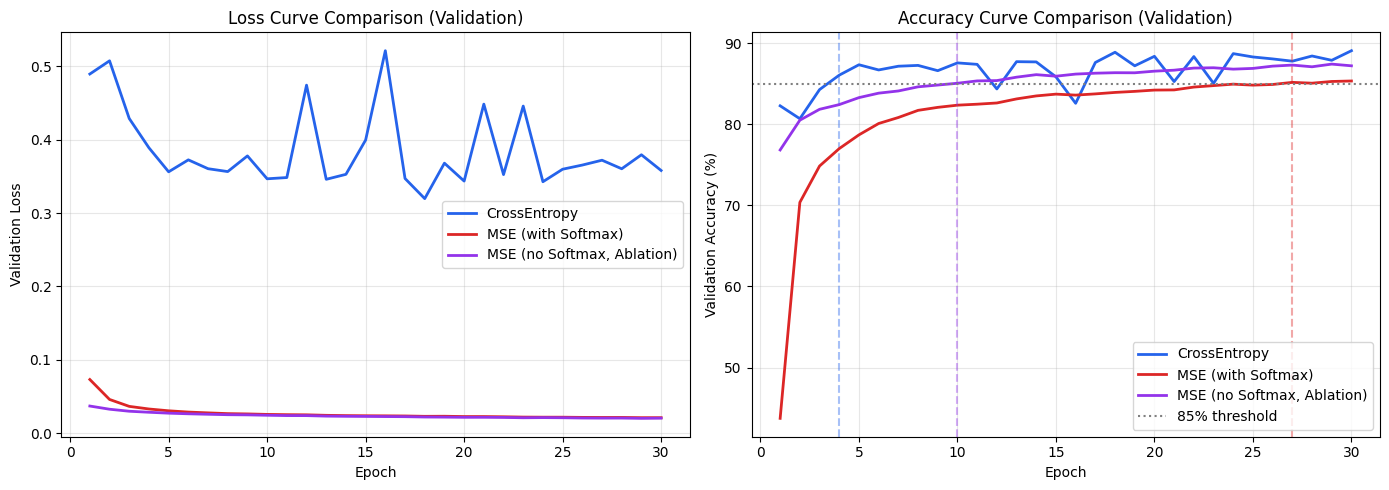

In [ ]:
# ====== 학습 곡선 오버레이 비교 ======
# 세 손실 모드의 Loss/Accuracy 곡선을 같은 축에 겹쳐 그려서 직관적 비교

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
color_palette = {"ce": "#2563EB", "mse_softmax": "#DC2626", "mse_raw": "#9333EA"}

# (1) Loss 곡선 비교 (Validation Loss 기준)
for mode in loss_modes_to_run:
    log = all_logs[mode]
    epochs_axis = range(1, len(log.val_losses) + 1)
    axes[0].plot(epochs_axis, log.val_losses,
                 label=mode_display_names[mode],
                 color=color_palette[mode], linewidth=2)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation Loss")
axes[0].set_title("Loss Curve Comparison (Validation)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# (2) Accuracy 곡선 비교 (Validation Accuracy 기준)
for mode in loss_modes_to_run:
    log = all_logs[mode]
    epochs_axis = range(1, len(log.val_accs) + 1)
    axes[1].plot(epochs_axis, [a*100 for a in log.val_accs],
                 label=mode_display_names[mode],
                 color=color_palette[mode], linewidth=2)
    # 수렴 시점 표시
    if log.convergence_epoch is not None:
        axes[1].axvline(x=log.convergence_epoch, color=color_palette[mode],
                        linestyle="--", alpha=0.4)

# 수렴 임계선
axes[1].axhline(y=CFG.convergence_threshold * 100, color="gray",
                linestyle=":", label=f"{CFG.convergence_threshold*100:.0f}% threshold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation Accuracy (%)")
axes[1].set_title("Accuracy Curve Comparison (Validation)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

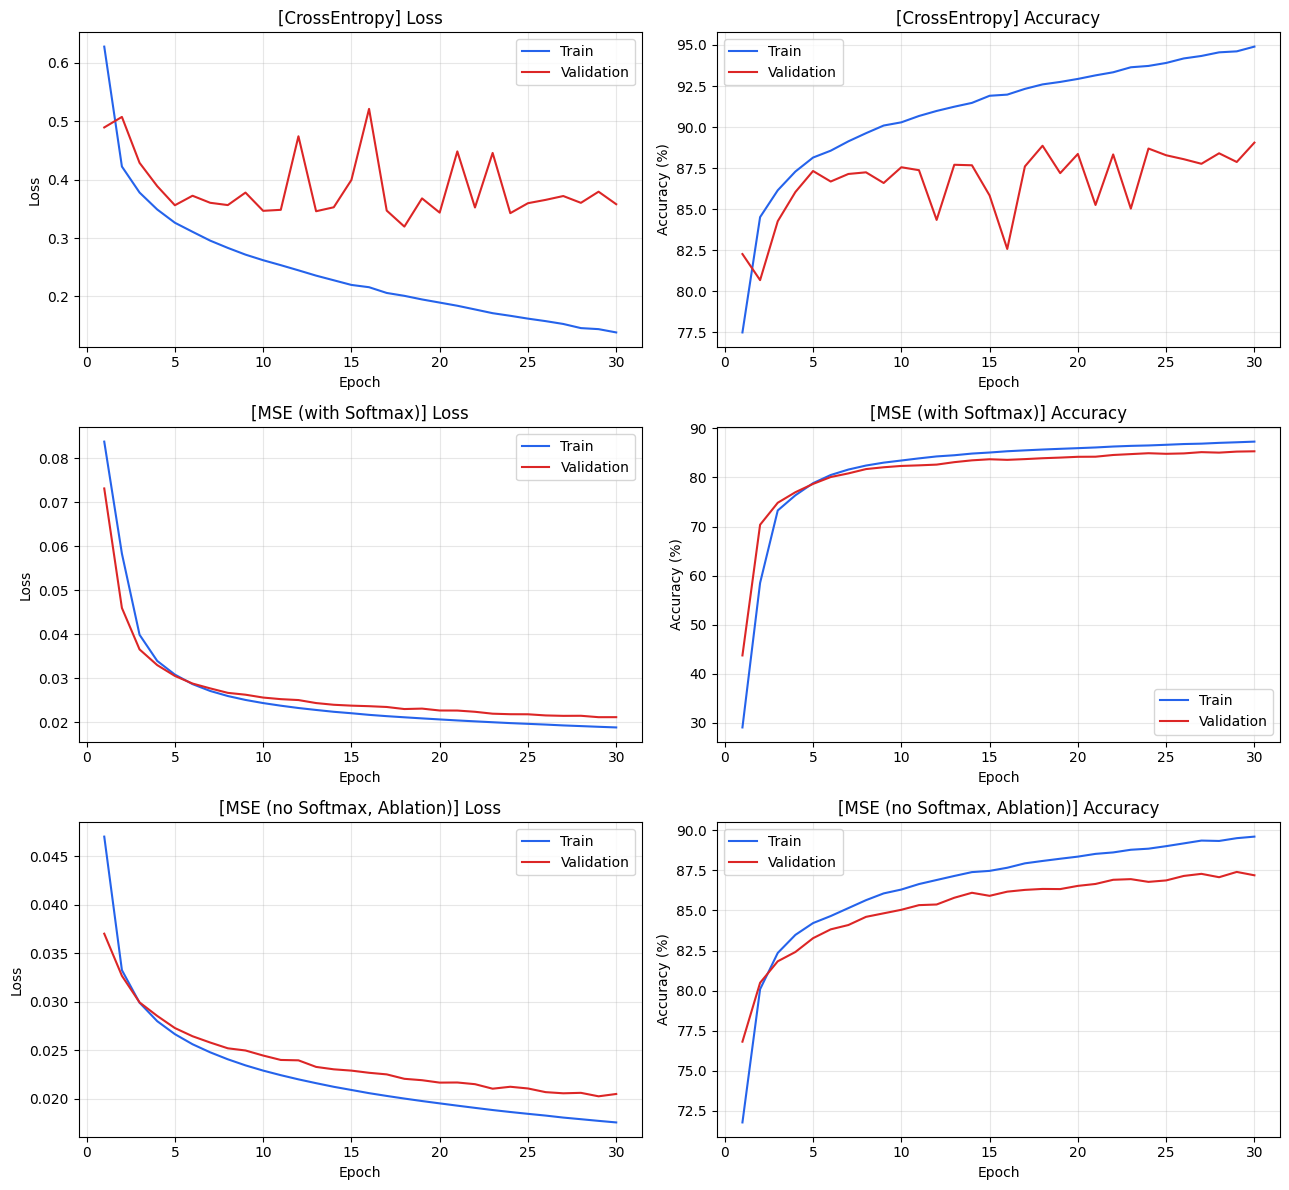

In [ ]:
# ====== 각 손실 모드별 Train vs Val 곡선 ======
# 과적합 여부, 진동 구간 확인용

fig, axes = plt.subplots(len(loss_modes_to_run), 2,
                          figsize=(13, 4 * len(loss_modes_to_run)))

for row, mode in enumerate(loss_modes_to_run):
    log = all_logs[mode]
    epochs_axis = range(1, len(log.train_losses) + 1)

    # Loss
    axes[row, 0].plot(epochs_axis, log.train_losses, label="Train", color="#2563EB")
    axes[row, 0].plot(epochs_axis, log.val_losses, label="Validation", color="#DC2626")
    axes[row, 0].set_xlabel("Epoch")
    axes[row, 0].set_ylabel("Loss")
    axes[row, 0].set_title(f"[{mode_display_names[mode]}] Loss")
    axes[row, 0].legend()
    axes[row, 0].grid(alpha=0.3)

    # Accuracy
    axes[row, 1].plot(epochs_axis, [a*100 for a in log.train_accs], label="Train", color="#2563EB")
    axes[row, 1].plot(epochs_axis, [a*100 for a in log.val_accs], label="Validation", color="#DC2626")
    axes[row, 1].set_xlabel("Epoch")
    axes[row, 1].set_ylabel("Accuracy (%)")
    axes[row, 1].set_title(f"[{mode_display_names[mode]}] Accuracy")
    axes[row, 1].legend()
    axes[row, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

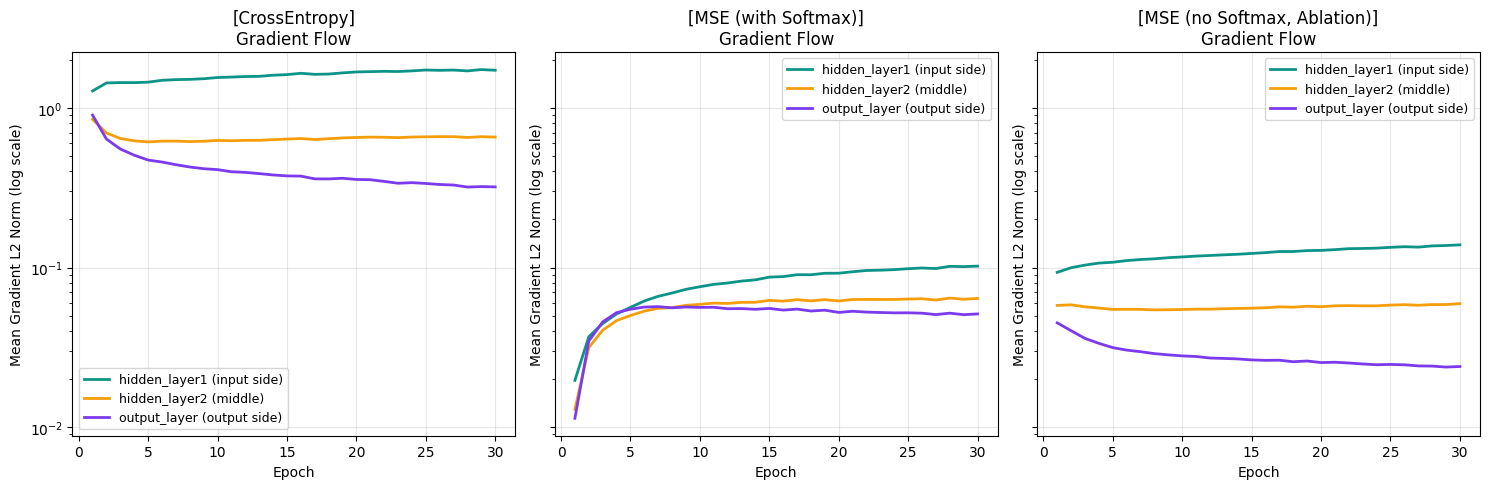


[Gradient norm ratio at final epoch (input side / output side)]
  CrossEntropy                  : 5.3828e+00
  MSE (with Softmax)            : 1.9930e+00
  MSE (no Softmax, Ablation)    : 5.7887e+00

Note: smaller ratio means gradient is not propagating well to input-side layers (vanishing signal)


In [ ]:
# ====== Gradient Norm 추이 시각화 ======
# 에폭별 각 레이어 gradient의 L2 norm 평균을 추적
# 특히 MSE에서 hidden_layer1의 gradient가 더 빨리 소실되는지 확인

fig, axes = plt.subplots(1, len(loss_modes_to_run),
                          figsize=(5 * len(loss_modes_to_run), 5),
                          sharey=True)

for col, mode in enumerate(loss_modes_to_run):
    log = all_logs[mode]
    epochs_axis = range(1, len(log.grad_norms_h1) + 1)

    axes[col].plot(epochs_axis, log.grad_norms_h1, label="hidden_layer1 (input side)",
                   color="#0D9488", linewidth=2)
    axes[col].plot(epochs_axis, log.grad_norms_h2, label="hidden_layer2 (middle)",
                   color="#F59E0B", linewidth=2)
    axes[col].plot(epochs_axis, log.grad_norms_out, label="output_layer (output side)",
                   color="#7C3AED", linewidth=2)
    # 로그 스케일로 동적 범위 압축
    axes[col].set_yscale("log")
    axes[col].set_xlabel("Epoch")
    axes[col].set_ylabel("Mean Gradient L2 Norm (log scale)")
    axes[col].set_title(f"[{mode_display_names[mode]}]\nGradient Flow")
    axes[col].legend(fontsize=9)
    axes[col].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 정량 비교: 학습 마지막 시점 gradient norm 비율
# 입력 측 레이어의 gradient가 출력 측보다 훨씬 작으면 vanishing 신호
print("\n[Gradient norm ratio at final epoch (input side / output side)]")
for mode in loss_modes_to_run:
    log = all_logs[mode]
    ratio = log.grad_norms_h1[-1] / (log.grad_norms_out[-1] + 1e-12)
    print(f"  {mode_display_names[mode]:<30}: {ratio:.4e}")
print("\nNote: smaller ratio means gradient is not propagating well to input-side layers (vanishing signal)")

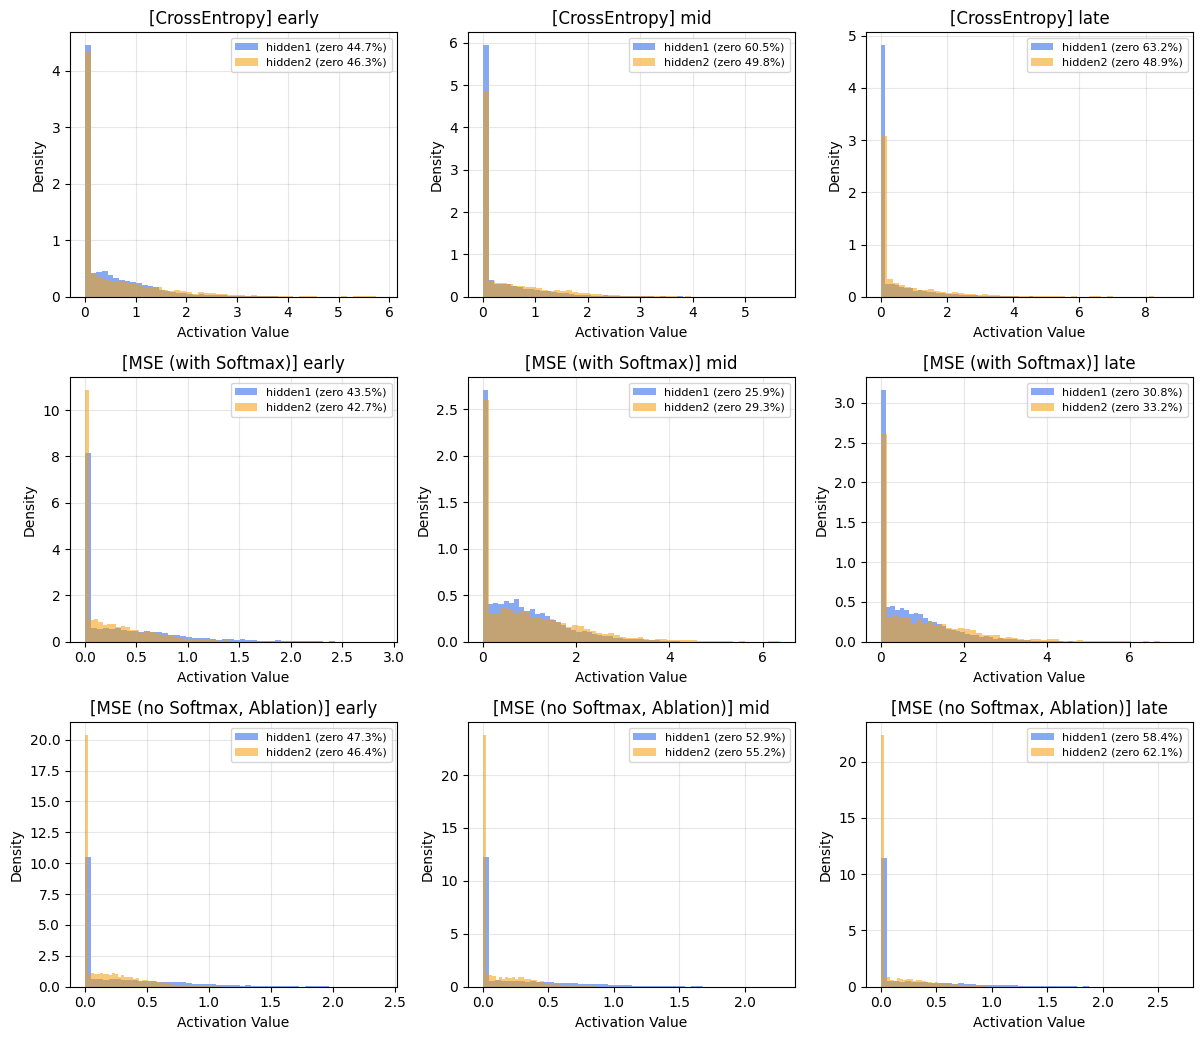

In [ ]:
# ====== 학습 단계별 Activation 분포 ======
# 학습 초반/중반/후반 시점에서 hidden layer ReLU 출력의 분포를 히스토그램으로 비교

# 학습 단계별 Activation 분포
# 학습 초/중/후반 시점에서 hidden layer ReLU 출력의 분포를 히스토그램으로 비교

stage_order = ["early", "mid", "late"]
layer_order = ["hidden1", "hidden2"]

fig, axes = plt.subplots(len(loss_modes_to_run), len(stage_order),
                          figsize=(4 * len(stage_order), 3.5 * len(loss_modes_to_run)),
                          sharex=False)

for row, mode in enumerate(loss_modes_to_run):
    recorder = all_activations[mode]
    for col, stage in enumerate(stage_order):
        ax = axes[row, col] if len(loss_modes_to_run) > 1 else axes[col]

        captured = recorder.captured.get(stage, {})
        for layer_id, color in zip(layer_order, ["#2563EB", "#F59E0B"]):
            if layer_id in captured:
                vals = captured[layer_id]
                # ReLU 출력에 0이 많을 수 있어 0 비율 함께 표시
                zero_pct = (vals == 0).mean() * 100
                ax.hist(vals, bins=50, alpha=0.55, color=color,
                        label=f"{layer_id} (zero {zero_pct:.1f}%)", density=True)

        ax.set_title(f"[{mode_display_names[mode]}] {stage}")
        ax.set_xlabel("Activation Value")
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()